In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from utils import multi_hot_encode, prepare_recommender_data, load_loss_val
from Models.recommender_model_code import MovieRecommender

RANDOM_STATE = 36
SEED = 1234

# 1. Importing Data

In [22]:
movies = pd.read_csv('./MovieLens/movies.csv')
ratings = pd.read_csv('./MovieLens/ratings.csv')

print(movies.shape, ratings.shape)
print(movies.columns, ratings.columns)

(9742, 3) (100836, 4)
Index(['movieId', 'title', 'genres'], dtype='str') Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')


In [23]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [24]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


# 2. Encoding Genres Column

In [25]:
genres = [
    "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir",
    "Horror", "IMAX", "Musical", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western"
]
genre_col = movies['genres']

encoded_columns = multi_hot_encode(genres, genre_col)

movies['genres_encoded'] = encoded_columns


# Mergrin encoded Gernes to Ratings DataFrame

In [26]:
ratings = ratings.merge(
    movies[['movieId', 'genres_encoded']], # Columns
    how='left', # Ratings is the main Df
    on='movieId' # Match based on movieId column
)

# Dropping TimeStamp Column

In [27]:
ratings = ratings.drop('timestamp', axis=1)

In [28]:
ratings

,userId,movieId,rating,genres_encoded
0,1,1,4.0,"[0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
1,1,3,4.0,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
2,1,6,4.0,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1,47,5.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
4,1,50,5.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...
100831,610,166534,4.0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, ..."
100832,610,168248,5.0,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
100833,610,168250,5.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
100834,610,168252,5.0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Train/Validation Splitting Data

In [29]:
train_data , cv_data = train_test_split(ratings, test_size=0.2, random_state=RANDOM_STATE)

print(train_data.shape, cv_data.shape)
cv_data.head()

(80668, 4) (20168, 4)


,userId,movieId,rating,genres_encoded
43714,292,4643,3.0,"[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
40452,274,59604,3.5,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, ..."
93719,599,3735,3.0,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
63442,414,3535,4.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, ..."
60720,391,3717,2.0,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Preparing Recommender NN Data

In [30]:
X_user_train, y_train, X_movie_train, train_movie_ids, X_user_cv, X_movie_cv, y_cv, cv_movie_ids = prepare_recommender_data(train_data, cv_data)

X_user_train.shape, y_train.shape, X_movie_train.shape, train_movie_ids.shape, X_user_cv.shape, X_movie_cv.shape, y_cv.shape, cv_movie_ids.shape

((80668,),
 (80668,),
 (80668, 19),
 (80668,),
 (20168,),
 (20168, 19),
 (20168,),
 (20168,))

---
# Training Model

In [ ]:
num_users = np.unique(X_user_train).shape[0] # 610

# model = tf.keras.models.load_model('Models/movie_recommender_pro3.keras')
model = MovieRecommender(num_users=num_users, l2_lambda=0)

model.summary()

Model: "movie_recommender_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_model (Sequential)         │ (None, 64)             │        39,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ movie_model (Sequential)        │ (None, 64)             │        46,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ interaction_model (Sequential)  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,376 (333.50 KB)

 Trainable params: 85,376 (333.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile & Fit
Saved The model Since it took me 5 Minutes each time to train it

In [32]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(0.001),
    loss = tf.keras.losses.MeanSquaredError()
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    [X_user_train.reshape(-1, 1), X_movie_train], y_train,
    validation_data=([X_user_cv.reshape(-1, 1), X_movie_cv], y_cv),
    epochs=20,
    callbacks=[early_stopping]
)


Epoch 1/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.9607 - val_loss: 0.8491
Epoch 2/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.8652 - val_loss: 0.8384
Epoch 3/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 0.8561 - val_loss: 0.8729
Epoch 4/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.8482 - val_loss: 0.8389
Epoch 5/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.8437 - val_loss: 0.8404


# Plotting Trianing and Val Loss 

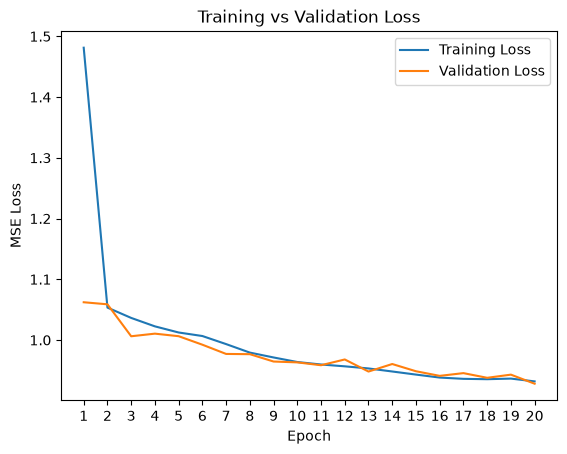

In [33]:
#? The loss & validation loss i got from training the model
loss, val_loss = load_loss_val()

plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.xticks(ticks=range(len(loss)), labels=range(1, len(loss) + 1))

plt.legend()
plt.show()

In [34]:
pred_train = model.predict([X_user_train, X_movie_train])

2521/2521 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


In [35]:
mse_train = mean_squared_error(y_train, pred_train)
mse_train

0.8284214337325244

In [36]:
for actual, predicted in zip(y_train[:5], pred_train[:5]):
    print(f'Actual: {actual}, Predicted: {predicted}')

Actual: 4.5, Predicted: [3.456027]
Actual: 3.5, Predicted: [3.8980598]
Actual: 1.0, Predicted: [2.867987]
Actual: 5.0, Predicted: [3.8937833]
Actual: 4.0, Predicted: [4.0748715]


In [37]:
actual = y_train
pred = pred_train.flatten()

print("Actual mean:", actual.mean())
print("Pred mean:", pred.mean())

print("Actual std:", actual.std())
print("Pred std:", pred.std())

correlation = np.corrcoef(
    y_train,
    pred_train.flatten()
)[0, 1]

print('Coef:', correlation)

Actual mean: 3.49911984925869
Pred mean: 3.5226831
Actual std: 1.0434030420375935
Pred std: 0.50450355
Coef: 0.4895013533399164


In [38]:
print(ratings.groupby("userId").size().describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


In [ ]:
# model.save('pro4_changed_architecture&l2reg.keras')